<a href="https://colab.research.google.com/github/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/Sesion_02_intuicion_estadistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
from scipy import optimize
from scipy.stats import norm
#plt.rcParams['text.usetex'] = True

"""
Este notebook es reproducido con base al curso del profesor
Raul Pollar
github:
# Machine Learning

Para más detalles y complementos ver:

Notas:
# Machine Learning online
https://rramosp.github.io/ai4eng.v1.20211.udea/content/LAB%2007.02%20-%20NEURAL%20NETWORKS.html
"""

'\nEste notebook es reproducido con base al curso del profesor\nRaul Pollar\ngithub:\n# Machine Learning\n\nPara más detalles y complementos ver:\n\nNotas:\n# Machine Learning online\nhttps://rramosp.github.io/ai4eng.v1.20211.udea/content/LAB%2007.02%20-%20NEURAL%20NETWORKS.html\n'


# 1. Dimension

Distribución normal:

\begin{equation}
f(x)=\frac{e^{-(\frac{x-\mu}{\sigma})^2/2}}{\sigma \sqrt(2\pi)}
\end{equation}

In [2]:
# Supongamos que tenemos datos los cuales siguen una distribucion de probabilidad normal
# Emplemos la librerÍa stats norm de scipy:

# https://docs.scipy.org/doc/scipy-0.13.0/reference/generated/scipy.stats.norm.html

# The location (loc) keyword specifies the mean mu.
# The scale (scale) keyword specifies the standard deviation sigma.


In [3]:
stats.norm?

> ```python
> """Variable aleatoria continua con distribución normal"""
> stats.norm(loc, scale)
>
> -> loc: # Media
> -> scale: # Desviación estándar
> ```


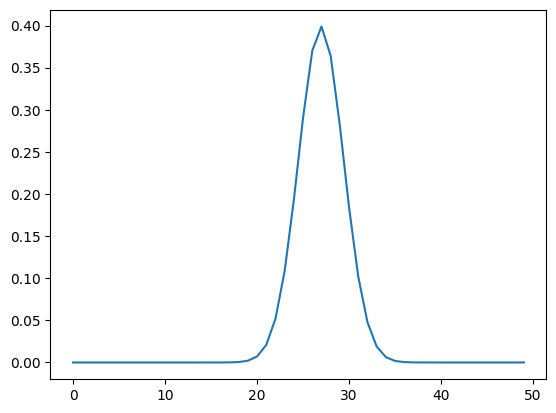

In [4]:
f1 = stats.norm(loc = 1, scale = 1)
plt.plot(f1.pdf(np.linspace(-10, 10)))
plt.show()

In [5]:
#def pdf(x, mean1 = 10, mean2=12, desv1=2, desv2=2):
#  fig, ax = plt.subplots(1, 1)

#  f1 = stats.norm(loc = mean1, scale = desv1)
#  f2 = stats.norm(loc = mean2, scale = desv2)
#  ax.plot(x, f1.pdf(x),'g-', lw = 3, alpha = 0.6, label='pdf 1')
#  ax.plot(x, f2.pdf(x),'b-', lw = 3, alpha = 0.6, label='pdf 2')
#  ax.set_xlabel("x")
#  ax.set_ylabel("PDF(X)")
#  return "Done", f1, f2

### Clasificación de colecciones que siguen dos distribuciones normales que se intersecan

Text(0, 0.5, 'PDF(X)')

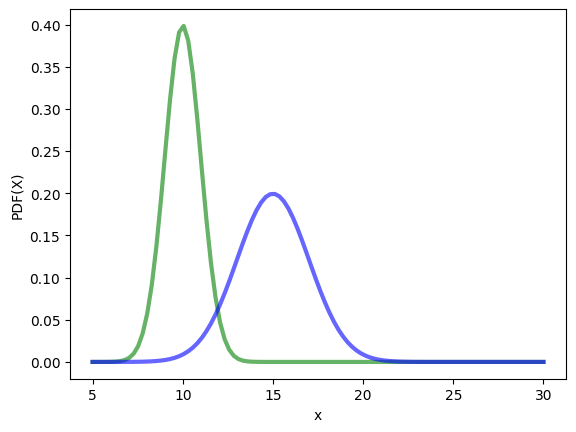

In [6]:
mean1 = 10
mean2=15
desv1=1
desv2=2
f1 = stats.norm(loc = mean1, scale = desv1)
f2 = stats.norm(loc = mean2, scale = desv2)
x=np.linspace(5, 30,100)

fig, ax = plt.subplots(1, 1)
fig.suptitle('')
ax.plot(x, f1.pdf(x),'g-', lw = 3, alpha = 0.6, label='pdf 1')
ax.plot(x, f2.pdf(x),'b-', lw = 3, alpha = 0.6, label='pdf 2')
ax.set_xlabel("x")
ax.set_ylabel("PDF(X)")

In [7]:
#x=np.linspace(5, 30,100)
#_, f1, f2 = pdf(x, mean1 = 12, mean2 = 15, desv1 = 1, desv2 = 2)
#plt.legend()

¿Si tenemos que decidir si un dato pertenece a la poblacion verde o azul como lo hariamos? ¿ Si definimos regiones asociadas a poblaciones como se puede encontrar la frontera en este caso?

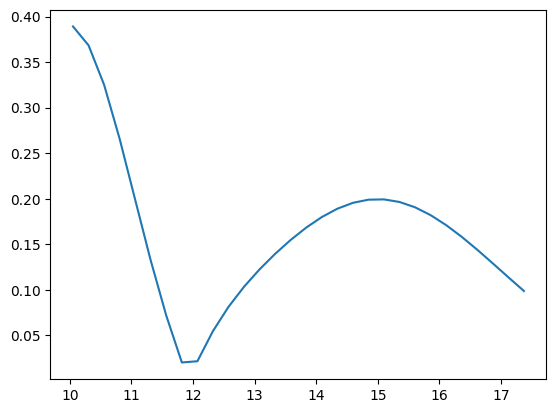

In [8]:
# Determinamos el mínimo
x_min_index = 20
x_min_max = x[x_min_index:50]
plt.plot(x_min_max, abs(f2.pdf(x_min_max)-f1.pdf(x_min_max)))


In [9]:
index_min = np.argmin(abs(f2.pdf(x_min_max) - f1.pdf(x_min_max)))
f_min = min(abs(f2.pdf(x_min_max) - f1.pdf(x_min_max)))
xmin_= x[x_min_index + index_min]

print(f"index min :{index_min}, function min : {f_min}, x min: {xmin_}")

index min :7, function min : 0.02012484531241352, x min: 11.818181818181818


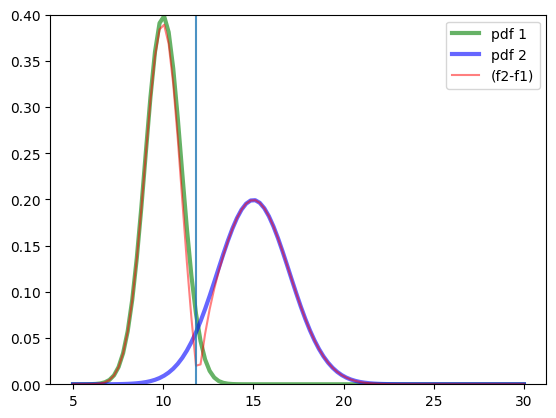

In [ ]:
#x = np.linspace(5, 30,1000)
#_, f1, f2 = pdf(x, mean1 = 12, mean2 = 17, desv1 = 1, desv2 = 2)
plt.plot(x, f1.pdf(x),'g-', lw = 3, alpha = 0.6, label='pdf 1')
plt.plot(x, f2.pdf(x),'b-', lw = 3, alpha = 0.6, label='pdf 2')
plt.plot(x,abs(f2.pdf(x)-f1.pdf(x)), "r-", alpha=0.5, label="(f2-f1)")

plt.vlines(xmin_, 0, 1, alpha=0.8)
plt.ylim(0,0.4)
plt.legend()

La función de distribucion cumulativa, viene dada por:

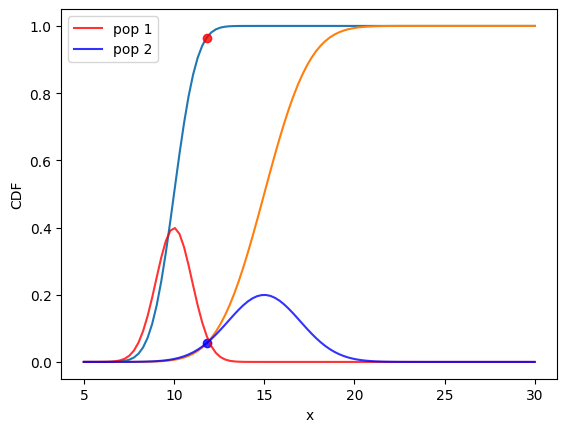

In [ ]:
plt.plot(x, f1.cdf(x))
plt.plot(xmin_, f1.cdf(xmin_),"ro", alpha=0.8)

plt.plot(x,f2.cdf(x))
plt.plot(xmin_,f2.cdf(xmin_),"bo", alpha=0.8)

plt.plot(x, f1.pdf(x), color="red", label="pop 1", alpha=0.8)
plt.plot(x, f2.pdf(x), color="blue", label="pop 2",alpha=0.8)
plt.xlim()
plt.ylabel("CDF")
plt.xlabel("x")
plt.legend()
plt.show()

In [ ]:
# El error de la clasificación con este módelo puede ser calculado como :
e1 = 1-f1.cdf(xmin_)
e2 = f2.cdf(xmin_)

# Error asociado a cada distribución de probabilidad
print(f"{e1*100:.2f} % {e2*100:.1f} % ")

# Se puede hacer zero este error?
# Como cambia este error a medida que las poblaciones estan mas mezcladas?
# ¿Hay que cambiar de modelo?

3.45 % 5.6 % 


Analicemos otra situación, aplicando un algoritmo de machine learning:





In [ ]:
# Supongamos que tenemos un sistema que puede arrojar valores binarios según una característica,
#es decir, pertenece a la clase 1 o clase 2 según sea el valor de la características


In [ ]:
x = np.linspace(5, 30,100)
#_, f1, f2 = pdf(x, mean1 = 12, mean2 = 17, desv1 = 1, desv2 = 2)

Elijamos un conjunto de valores

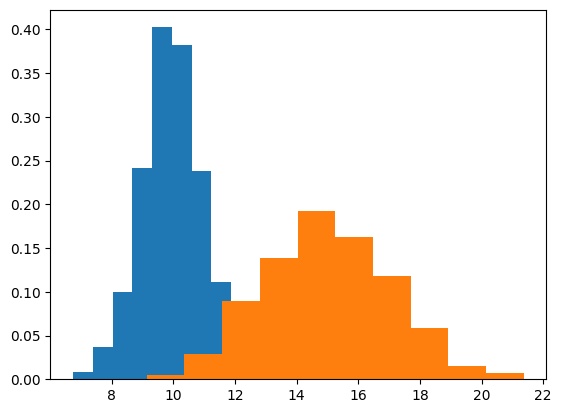

In [ ]:
random_1 = f1.rvs(1000)
random_2 = f2.rvs(1000)

plt.figure()
plt.hist(random_1, density=True)
#plt.plot(x, f1.pdf(x))
plt.hist(random_2, density=True)
#plt.plot(x, f2.pdf(x))
plt.show()

In [ ]:
#Generamos N datos para cada distribucion de probabilidad a partir de variables
# aleatorias
m = 100 # training values

random_1 = f1.rvs(m)  #m variables aleatorias pertenecientes a la clase 1
random_2 = f2.rvs(m)  #m variables aleatorias pertenecientes a la clase 2

X = np.zeros(2*m)
X[0:m] = random_1
X[m:2*m] = random_2  # Construcción de vector con la característica 1

Y = np.zeros(2*m)    # Valor asociada a la caracteristica 1
Y[m:2*m] = np.ones(m)

El dataset anterior puede ser escrito como:

|Y         | X_1       |
|----------|----------|
|$Y^{1}$ | $X_1^{1}$|
|$Y^{2}$ | $X_1^{2}$|
|.         | .        |
|.         | .        |
|.         | .        |
|$Y^{m}$ | $X_1^{m}$  |




([], [])

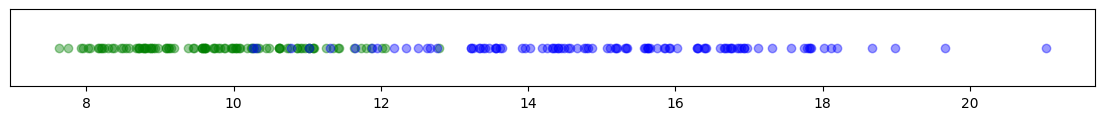

In [ ]:
#De forma grafica puede ser entendido asi:
plt.figure(figsize=(14,1))
plt.plot(X[Y==0],np.zeros(m),"go", alpha=0.4)
plt.plot(X[Y==1],np.zeros(m),"bo", alpha=0.4)
plt.yticks([])

### Árboles de decisión

¿Como podemos obtener un estimado de la frontera a partir de los datos?

- Empleemos diferentes algoritmos para hacerlo:




In [ ]:
from sklearn.tree import DecisionTreeClassifier
X = X.reshape(-1, 1)
clf = DecisionTreeClassifier(max_depth = 1)  # Estimador
clf = clf.fit(X, Y)
#f2.rvs(1).reshape(1, -1)                       # Fit
print(f"Score: {clf.score(X, Y)}")           # Score
clf.predict(f2.rvs(1).reshape(1, -1))

Score: 0.955


array([1.])

In [ ]:
f2.rvs(1)

array([14.13506012])

 Analicemos gráficamente las fronteras:

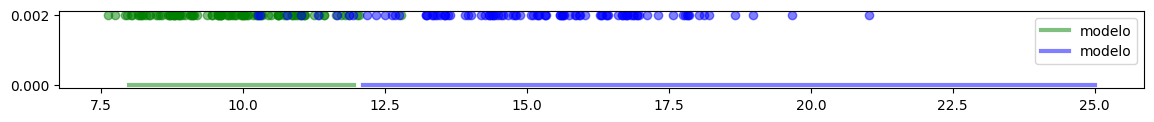

In [ ]:
# dado un nuevo conjunto de puntos, ¿qué puede estimar el algoritmo?
Xr = np.linspace(8, 25, 100).reshape(-1,1)   # Para un nuevo conjunto de datos, tentemos que la predicción es:
yr = clf.predict(Xr)
plt.figure(figsize=(14,1))
plt.plot(Xr[yr==0], np.zeros(len(Xr[yr==0]) ),color="g" ,alpha=0.5, lw=3, label="modelo" )  # GRaficando la prediccion para el conjunto de datos, para los de tipo 0
plt.plot(Xr[yr==1], np.zeros(len(Xr[yr==1]) ), color="b",alpha=0.5, lw =3 , label="modelo") #  GRaficando la prediccion para el conjunto de datos, para los de tipo 1
plt.plot(X[Y==0],0.002*np.ones(m),"go", alpha = 0.5) # Valores aleatorios # Valores de entrenamiento
plt.plot(X[Y==1],0.002*np.ones(m),"bo", alpha = 0.5)
plt.legend()
plt.show()


# Tarea


1. Definir una función que permita determinar m  valores de entrenamiento dado, Para  f1, f2  definidos como:

f1 = stats.norm(loc = mean1, scale = desv1)

f2 = stats.norm(loc = mean2, scale = desv2)

Emplee los valores de mean1=12, mean1=17, con desv1=1, desv2=2

Con base en ello,  construya una función de python, que permita determinar la predicción empleando un DesicionTreeClasifier

```
def train_values(m)
  """
  Params m
  Return X, y
  """

  return X, y
```



```
def main(X, y, Xr, m):    
  """
  Params:
      X : Features values
      y : training values for each features
      Xr : np.linspace(5, 25, 100).reshape(-1, 1) New Values for prediction
      m  : len of value of training
  Return :
      yr: Prediction
  """


  return yr
```


2. Con la función construida realice los siguientes experimentos:
  - Elija diferentes valores m entre  (10 , 100). ¿Cómo se compara la frontera (llamada frontera natural o también Bayesiana) respecto a los valores determinados?
  - Elija m=100, realice un muestreo para 10 experimentos, ¿Cómo se compara la frontera respecto a los valores determinados?


In [ ]:
#En resumen
def train_values(m = 100):

  random_1 = f1.rvs(m)  #m variables aleatorias pertenecientes a la clase 1
  random_2 = f2.rvs(m)  #m variables aleatorias pertenecientes a la clase 2

  X = np.zeros(2*m)
  X[0:m] = random_1
  X[m:2*m] = random_2  # Construccion de vector con la caracteristica 1

  y = np.zeros(2*m)    # Valor asociada a la caracteristica 1
  y[m:2*m] = np.ones(m)

  return X, y


def main(X, y, Xr, m):
  #X, y = train_values(100)
  clf = DecisionTreeClassifier(max_depth = 1)
  clf = clf.fit(X.reshape(-1, 1), y)

 # Xr = np.linspace(8,25, 100 ).reshape(-1, 1)
  yr = clf.predict(Xr)


  plt.figure(figsize=(14,1))
  plt.plot(Xr[yr==0], np.zeros(len(Xr[yr==0]) ), color="g", alpha=0.6, lw=3 )  # GRaficando la prediccion para el conjunto de datos, para los de tipo 0
  plt.plot(Xr[yr==1], np.zeros(len(Xr[yr==1]) ), color="b", alpha=0.6, lw =3 ) #  GRaficando la prediccion para el conjunto de datos, para los de tipo 1
  plt.plot(X[y==0],np.ones(m),"g.", alpha = 0.4) # Valores aleatorios # Valores de entrenamiento
  plt.plot(X[y==1],np.ones(m),"b.", alpha = 0.4)                      # Valores de test
  plt.yticks([])
  plt.show()

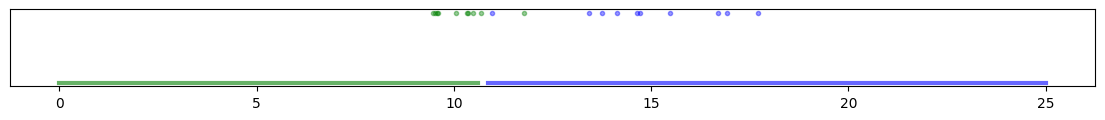

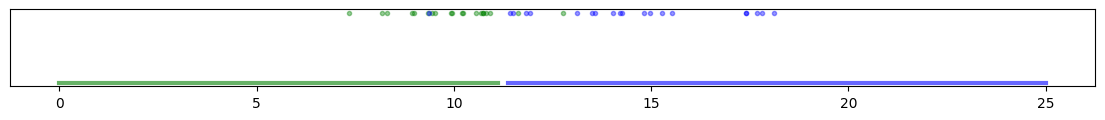

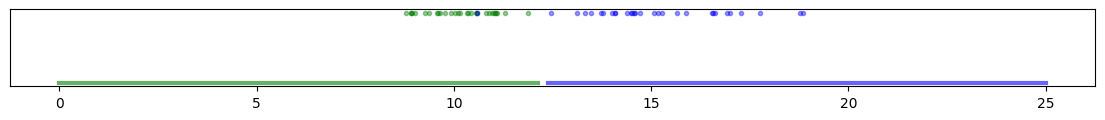

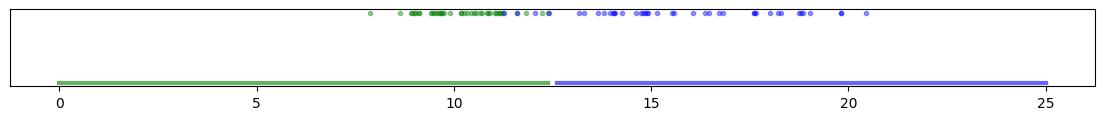

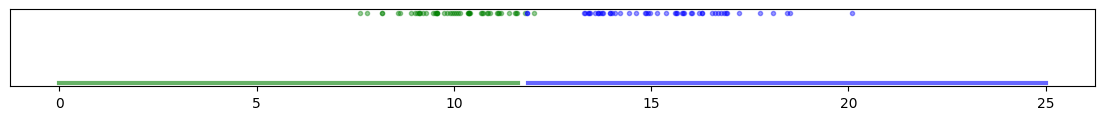

In [ ]:
# Para diferentes valores de datos de entrenamiento, el resultado es el siguiente:
m = np.arange(10, 60, 10)

for m_ in m:
  X, y = train_values(m_)
  Xr = np.linspace(0,25, 100 ).reshape(-1, 1)
  main(X, y, Xr,m_)

#Como cambia la frontera determinada por el algoritmo cuando el numero de datos es pequeño
# y aumenta el numero de datos?

In [ ]:
m = 1000*np.ones(5)
print(m)

[1000. 1000. 1000. 1000. 1000.]


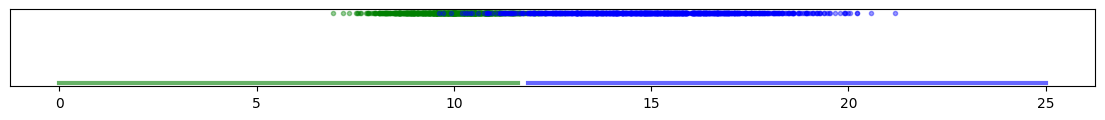

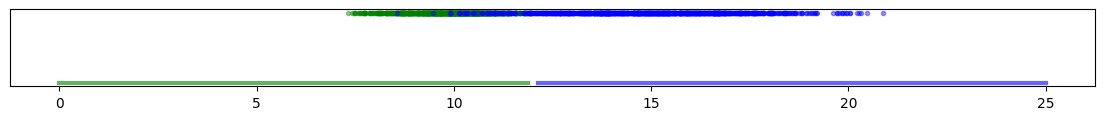

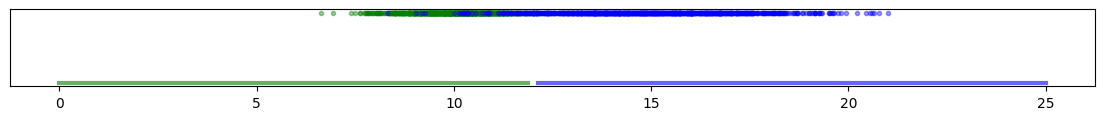

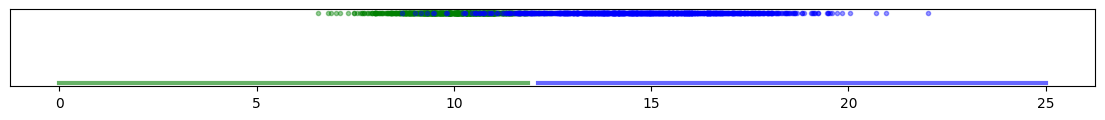

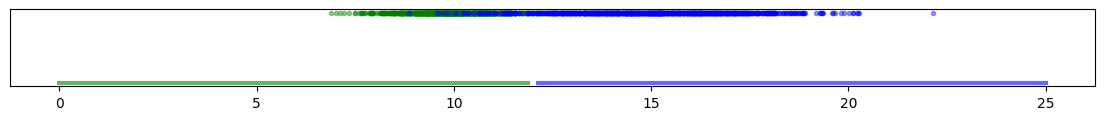

In [ ]:
# Realicemos un muestreo para m valores=100 experimentos
#m = 100*np.ones(5)
for m_ in m:
  m_=int(m_)
  X, y = train_values(m_)
  Xr = np.linspace(0,25, 100 ).reshape(-1, 1)
  main(X, y, Xr,m_)

#Reinicie todo el analisis con caso intermedio y cuando el modelo no es bueno


# 2 Dimensiones

Caso Bivariante

\begin{equation}
f(x, y) = \frac{1}{2\pi \sigma_x \sigma_y \sqrt{1-\rho^2}} \exp \left( -\frac{1}{2(1-\rho^2)} \left(\frac{x^2}{\sigma_x^2}+\frac{y^2}{\sigma_y^2}-\frac{2\rho x y}{(\sigma_x \sigma_y)} \right) \right)
\end{equation}


$\rho$ coeficiente de correlación, media es $(0, 0)$


La matriz de covarianzas viene dada por:

\begin{equation}
\Sigma =  
\begin{bmatrix}
\sigma_x^2 & \rho \sigma_x \sigma_y  \\
\rho \sigma_x \sigma_y & \sigma_y^2\\
\end{bmatrix}
\end{equation}

Otra forma de escribirla puede ser como sigue



### El caso más general viene dado por:

En el caso más general tenemos que :
\begin{equation}
f_X(x_1,x_2, ... x_n) = \frac{1}{2\pi^{n/2}|\Sigma|^{1/2}} \exp\left( -\frac{1}{2}(x-\mu)^T\Sigma^{-1}(x-\mu)\right)
\end{equation}


$|\Sigma|$ es el determinante de la matrix de covarianza,






In [ ]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import numpy as np
from sklearn.model_selection import train_test_split


## Funcion de distribucion de  probabilidad  1D

Text(0, 0.5, 'PDF(X)')

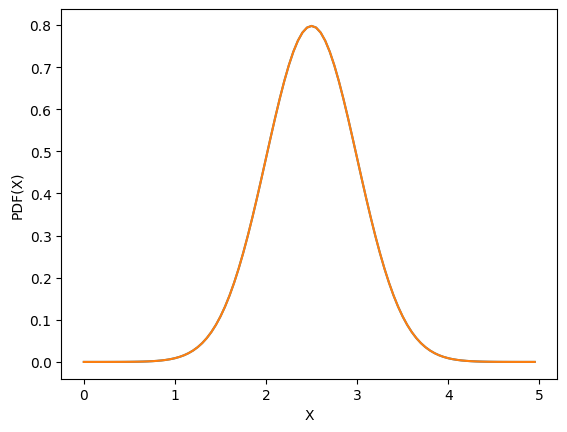

In [ ]:
x = np.linspace(0, 5, 100, endpoint=False)
y = multivariate_normal.pdf(x, mean = 2.5, cov = 0.25);

f1 = stats.norm(loc = 2.5, scale = np.sqrt((0.25)))

fig1 = plt.figure()
ax = fig1.add_subplot(111)
ax.plot(x, y)
ax.plot(x,f1.pdf(x))
ax.set_xlabel("X")
ax.set_ylabel("PDF(X)")


## Funcion de distribucion de  probabilidad  2D

In [ ]:
x, y = np.mgrid[-4:4:.1, -4:4:.1]
pos = np.dstack((x, y))
mu = [0.0, 0.0]                 # Centrada en el origen
cov = [[1.0, 0.0], [0.0, 1.0]]  # Matriz de covarianzas identidad -> Producto de dos dist
rv = multivariate_normal(mu, cov)

x1, y1 = np.mgrid[-4:4:.1, -4:4:.1]
pos1 = np.dstack((x1, y1))
mu1 = [0.0, 0.0]                 # Centrada en el origen
cov1 = [[1.0, -0.5], [-0.5, 1.0]]  # Matriz de covarianzas identidad -> Dist inversamente proporcionales
rv1 = multivariate_normal(mu1, cov1)

x2, y2 = np.mgrid[-4:4:.1, -4:4:.1]
pos2 = np.dstack((x2, y2))
mu2 = [0.0, 0.0]                 # Centrada en el origen
cov2 = [[1.0, 0.8], [0.8, 1]]  # Matriz de covarianzas identidad -> Dist proporcionales
rv2 = multivariate_normal(mu2, cov2)



#### Mapa de correlaciones

Text(0, 0.5, '$PDF(X_1, X_2)$')

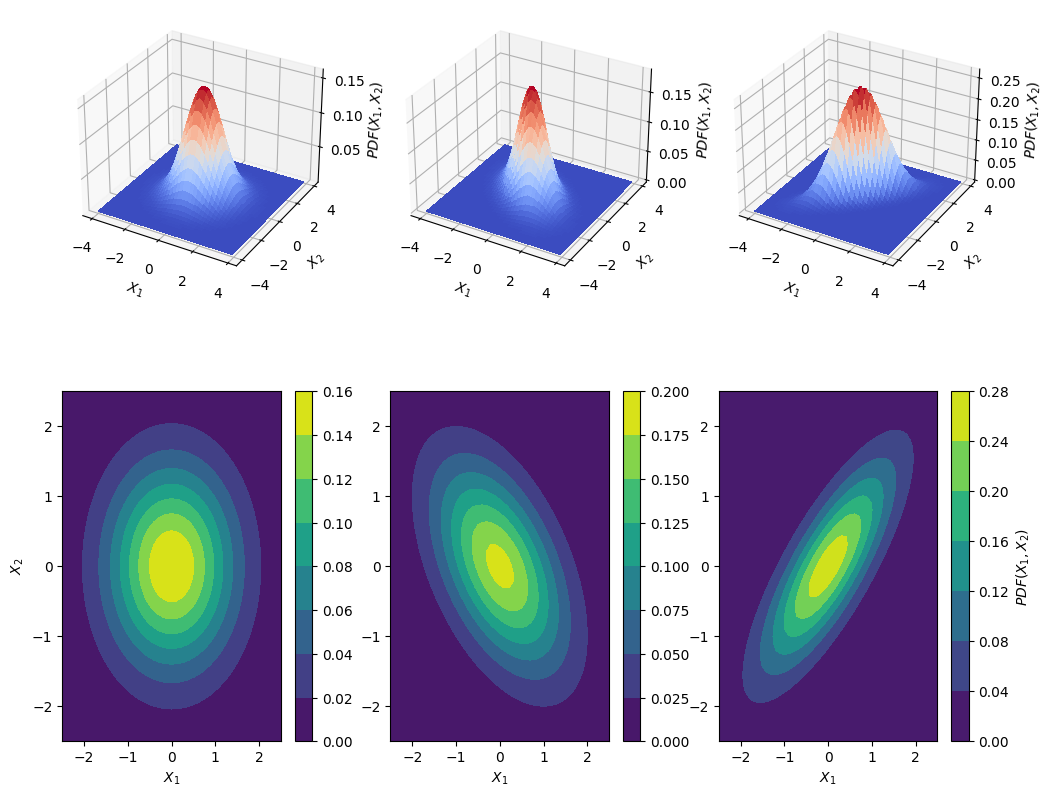

In [ ]:
# Set up a figure twice as tall as it is wide
fig = plt.figure(figsize = (12,10))

ax = fig.add_subplot(2, 3, 1, projection='3d')
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(x,y, rv.pdf(pos), cmap = cm.coolwarm,
                       linewidth = 0, antialiased = False)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$PDF(X_1,X_2)$")

ax = fig.add_subplot(2, 3, 2, projection='3d')
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(x1,y1, rv1.pdf(pos1), cmap = cm.coolwarm,
                       linewidth = 0, antialiased = False)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$PDF(X_1,X_2)$")


ax = fig.add_subplot(2, 3, 3, projection='3d')
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(x2,y2, rv2.pdf(pos2), cmap = cm.coolwarm,
                       linewidth = 0, antialiased = False)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$PDF(X_1,X_2)$")

#=============================================================
ax = fig.add_subplot(2, 3, 4)
cs = ax.contourf(x, y, rv.pdf(pos))
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)
cbar = fig.colorbar(cs)
#cbar.ax.set_ylabel('PDF(X_1, X_2)$')

ax = fig.add_subplot(2, 3, 5)
cs = ax.contourf(x1, y1, rv1.pdf(pos1))
ax.set_xlabel("$X_1$")
#ax.set_ylabel("$X_2$")
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)
cbar = fig.colorbar(cs)
#cbar.ax.set_ylabel('PDF(X_1, X_2)$')

ax = fig.add_subplot(2, 3, 6)
cs = ax.contourf(x2, y2, rv2.pdf(pos2))
ax.set_xlabel("$X_1$")
#ax.set_ylabel("$X_2$")
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)
cbar = fig.colorbar(cs)
cbar.ax.set_ylabel('$PDF(X_1, X_2)$')
#=============================================================


# Add the contour line levels to the colorbar


\begin{equation}
\mu =  
\begin{bmatrix}
0 \\
0 \\
\end{bmatrix}
\end{equation}

\begin{equation}
\Sigma =  
\begin{bmatrix}
1 & 0  \\
0 & 1\\
\end{bmatrix}
\end{equation}


\begin{equation}
\Sigma =  
\begin{bmatrix}
1 & 0.5  \\
0.5 & 1\\
\end{bmatrix}
\end{equation}


\begin{equation}
\Sigma =  
\begin{bmatrix}
1 & 0.8  \\
0.8 & 1\\
\end{bmatrix}
\end{equation}


Tomemos dos funcion de distribucion de probabilidad y realicemos un procedimiento analogo al descrito en 1D, en este caso, nos podemos preguntar
por ¿cual es el plano que permite separar dos distrubuciones?, es importante resaltar que cuando se esta trabajando con datos, generalmente no se conoce la distribucion de probablidad de los datos, solo hay un pequeña muestra  para la cual se desea minimizar el error respecto a la frontera Bayesiana.

Supongamos dos distrubuciones de datos,respresentados de la siguiente forma:

In [ ]:
# Caso mas visible
x, y = np.mgrid[-4:4:.1, -4:4:.1]
pos = np.dstack((x, y))
mu = [1, 1]                 # Centrada en el origen
cov = [[1.0, 0.0], [0.0, 1.0]]  # Matriz de covarianzas identidad
rv = multivariate_normal(mu, cov)

x1, y1 = np.mgrid[-4:4:.1, -4:4:.1]
pos1 = np.dstack((x1, y1))
mu1 = [-2, -2]                 # Centrada en el origen
cov1 = [[1.0, -0.5], [-0.5, 1.0]]  # Matriz de covarianzas identidad
rv1 = multivariate_normal(mu1, cov1)

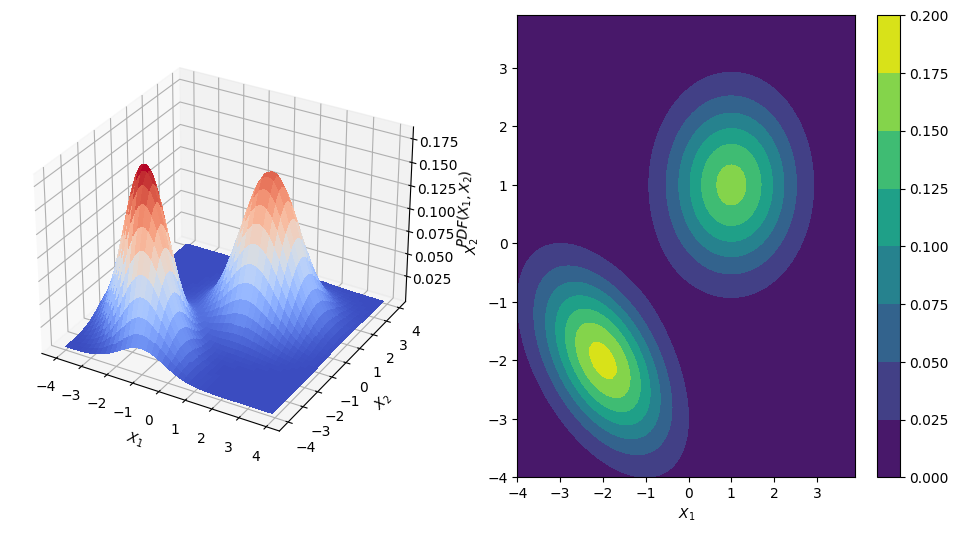

In [ ]:
fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax.plot_surface(x,y, rv.pdf(pos) + rv1.pdf(pos1), cmap = cm.coolwarm,
                       linewidth = 0, antialiased = False)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$PDF(X_1,X_2)$")
#=============================================================
ax = fig.add_subplot(1, 2, 2)
cs1 = ax.contourf(x, y, rv.pdf(pos) + rv1.pdf(pos1)  )
#cs2 = ax.contourf(x1, y1, rv1.pdf(pos1) )
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
#ax.set_xlim(-2.5,2.5)
#ax.set_ylim(-2.5,2.5)
cbar = fig.colorbar(cs1)



se requiere separar cada distribución con el fin de clasificar los datos.

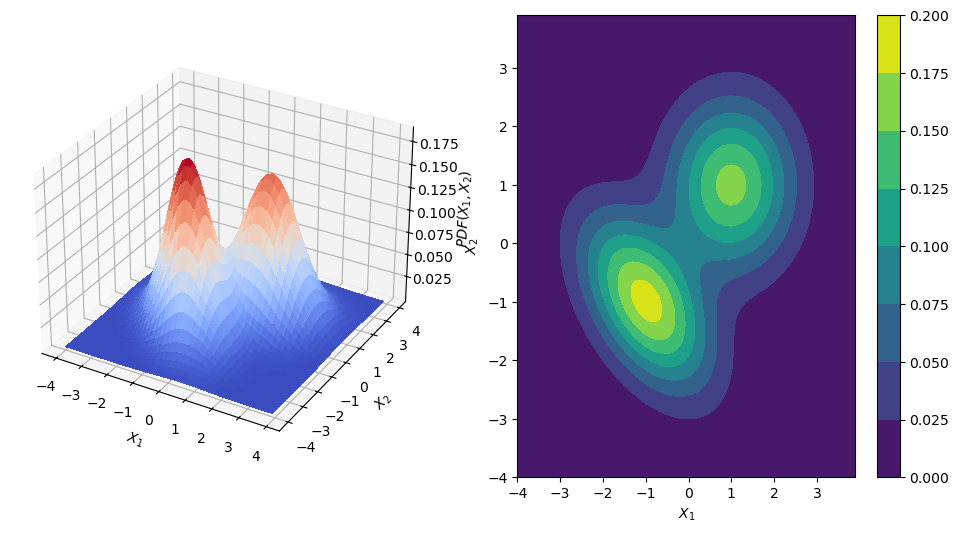

In [ ]:
# Caso
#=======================================================
x, y = np.mgrid[-4:4:.1, -4:4:.1]
pos = np.dstack((x, y))
mu = [1, 1]                 # Centrada en el origen
cov = [[1.0, 0.0], [0.0, 1.0]]  # Matriz de covarianzas identidad
rv = multivariate_normal(mu, cov)

x1, y1 = np.mgrid[-4:4:.1, -4:4:.1]
pos1 = np.dstack((x1, y1))
mu1 = [-1, -1]                 # Centrada en el origen
cov1 = [[1.0, -0.5], [-0.5, 1.0]]  # Matriz de covarianzas identidad
rv1 = multivariate_normal(mu1, cov1)
#=======================================================

fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax.plot_surface(x,y, rv.pdf(pos) + rv1.pdf(pos1), cmap = cm.coolwarm,
                       linewidth = 0, antialiased = False)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$PDF(X_1,X_2)$")
#=============================================================
ax = fig.add_subplot(1, 2, 2)
cs1 = ax.contourf(x, y, rv.pdf(pos) + rv1.pdf(pos1)  )
#cs2 = ax.contourf(x1, y1, rv1.pdf(pos1) )
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
#ax.set_xlim(-2.5,2.5)
#ax.set_ylim(-2.5,2.5)
cbar = fig.colorbar(cs1)



Supongamos, que podemos tener una muestra del  dataset(análogo a uando tiene un  problema NO ideal).

El dataset anterior puede ser escrito como:

|Y         | X_1       |X_2       |
|----------|----------|-----------|
|$Y^{1}$ | $X_1^{1}$|  $X_2^{1}$|
|$Y^{2}$ | $X_1^{2}$|$X_2^{1}$|
|.         | .        |.        |
|.         | .        |.        |
|.         | .        |.        |
|$Y^{m}$ | $X_1^{m}$  |$X_2^{1}$|


y, desde python puede ser generado como sigue:


#### Mapas de equipotenciales

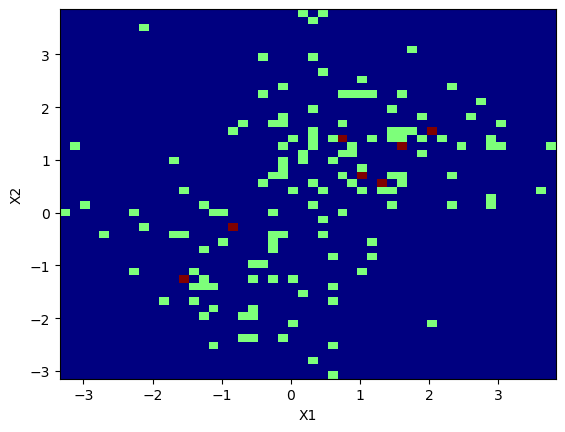

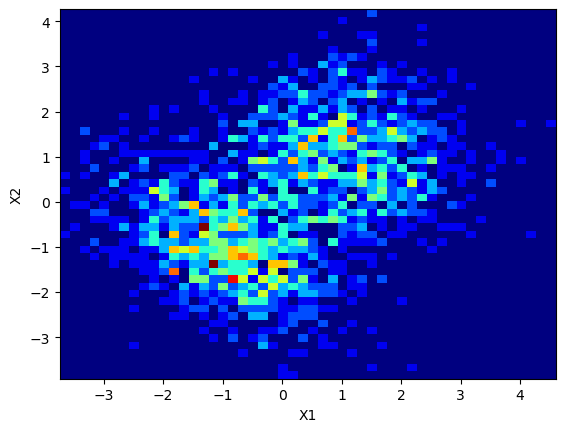

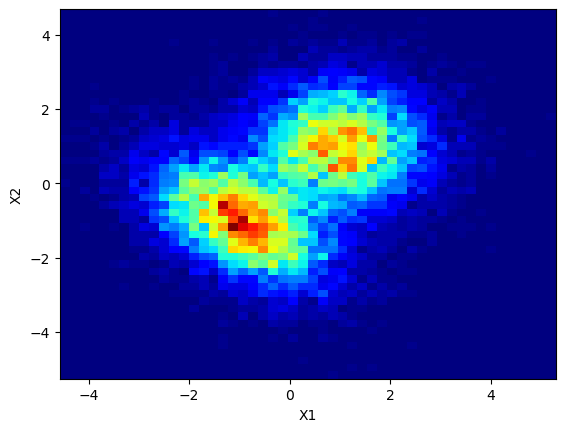

In [ ]:
# Histograma de los datos sinteticos a estudiar
N = 1000
def fig_2histogram(N1,N2):
  X_data1 = np.concatenate([rv.rvs(N1), rv1.rvs(N2)]) # Todos los datos en la misma distribución,
  #pertenecientes a dos clases
  plt.figure()
  plt.hist2d(X_data1[:,0], X_data1[:,1], bins=(50, 50), cmap=plt.cm.jet)
  #plt.figure()
  #plt.hist2d(X_data2[:,0], X_data2[:,1], bins=(50, 50), cmap=plt.cm.jet)
  plt.xlabel("X1")
  plt.ylabel("X2")
  plt.show()

fig_2histogram(N1 = 100,  N2 = 50)
fig_2histogram(N1 = 1000, N2 = 1000)
fig_2histogram(N1 = 10000,N2 = 10000)


In [ ]:
def sample(N1= 1000, N2 = 100):
  X_t = np.concatenate([rv.rvs(N1), rv1.rvs(N2)]) # Todos los datos en la misma distribución,
  y   = np.concatenate([np.zeros(N1), np.ones(N2) ]  )
  return X_t, y

Text(0, 0.5, 'X2')

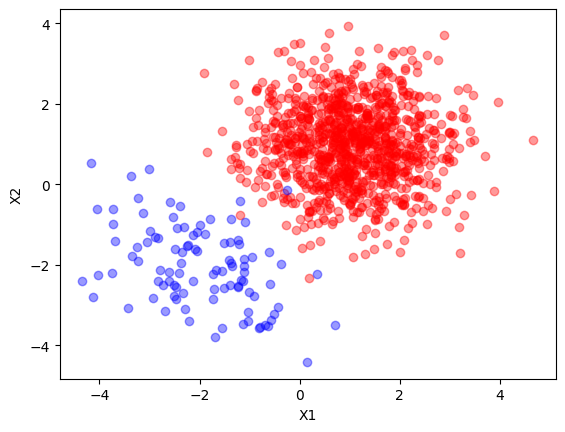

In [ ]:
X_t, y = sample()
plt.plot(X_t[y==0][:,0],X_t[y==0][:,1],"ro", alpha=0.4)
plt.plot(X_t[y==1][:,0],X_t[y==1][:,1],"bo", alpha=0.4)
plt.xlabel("X1")
plt.ylabel("X2")

# Tarea
¿Cómo se puede aproximar la frontera Bayesiana en este caso?. Implemente un algoritmo que permita determinarla

## Boundary
Librerias para dibujar la frontera:

https://scikit-learn.org/stable/auto_examples/svm/plot_iris_svc.html


In [ ]:
def make_meshgrid(x, y, h=0.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy


def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_contoursExact(ax, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

# Generation of Data

In [ ]:
#Un poco mas ordenada, la generacion de data
def data( mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]   ):# Caso mas visible
  rv = multivariate_normal(mu, cov)
  rv1 = multivariate_normal(mu1, cov1)
  return rv, rv1

def sample(N1= 1000, N2 = 100):
  X_t = np.concatenate([rv.rvs(N1), rv1.rvs(N2)]) # Todos los datos en la misma distribución,
  y   = np.concatenate([np.zeros(N1), np.ones(N2) ]  )
  return X_t, y


Text(0, 0.5, 'X2')

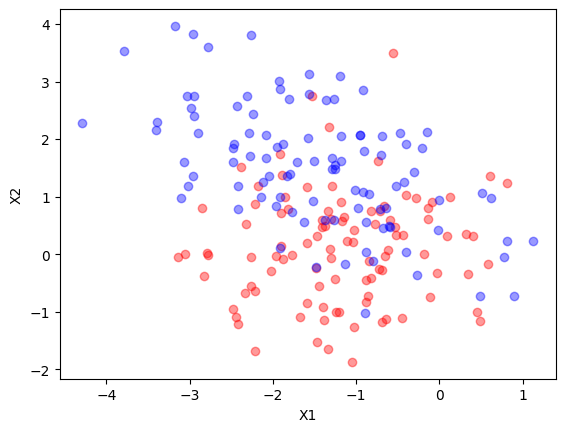

In [ ]:
rv, rv1 = data(mu=[-1.2, 0.2], mu1=[-1.5, 1.5],
               cov=[[1.0, 0.0], [0.0, 1.0]] ,
               cov1= [[1.0, -0.5], [-0.5, 1.0]] )

X_t, y = sample(N1 = 100, N2 = 100)
X_p, y_ = sample(N1 = 100, N2 = 100)

plt.plot(X_t[y==0][:,0],X_t[y==0][:,1],"ro", alpha=0.4)
plt.plot(X_t[y==1][:,0],X_t[y==1][:,1],"bo", alpha=0.4)
plt.xlabel("X1")
plt.ylabel("X2")



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_t, y,
                                                    test_size=0.33,
                                                    random_state=42)

# SVC



In [ ]:
X_t, y = X_train, y_train # Datos de entrenamiento
X_p, y_ = X_test, y_test  # Datos para la prediccion


0.7985074626865671


Text(0.5, 1.0, 'Valores Esperados')

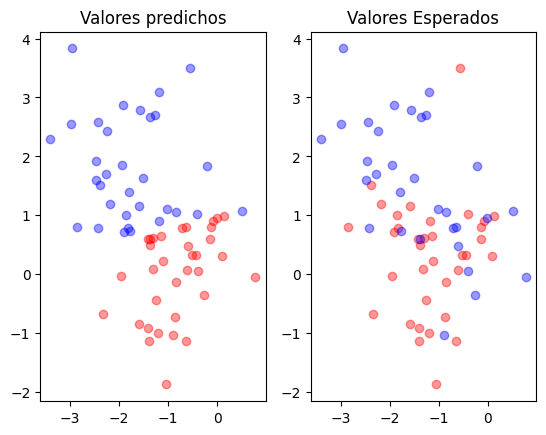

In [ ]:
from sklearn.svm import SVC
clf = SVC( gamma = 0.2)
clf.fit(X_t,y)
print('Puntaje con los datos de entrenamiento:', clf.score(X_t, y))
y_p = clf.predict(X_p)


plt.subplot(121)
plt.plot(X_p[y_p==0][:,0],X_p[y_p==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_p==1][:,0],X_p[y_p==1][:,1],"bo", alpha=0.4)
plt.title("Valores predichos")

plt.subplot(122)
plt.plot(X_p[y_==0][:,0],X_p[y_==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_==1][:,0],X_p[y_==1][:,1],"bo", alpha=0.4)
plt.title("Valores Esperados")


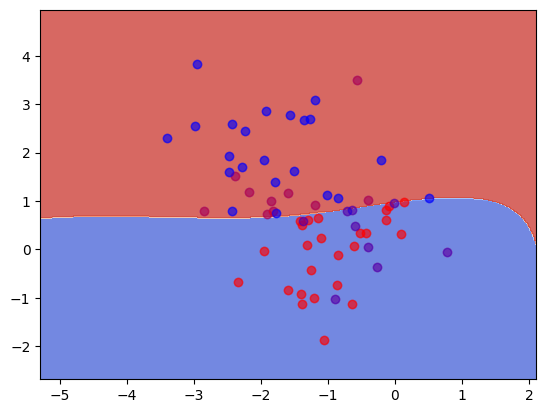

In [ ]:
fig, ax = plt.subplots()
# title for the plots
title = ('Decisión surface of linear SVC ')
# Set-up grid for plotting.
X0, X1 = X_t[:, 0], X_t[:, 1]
xx, yy = make_meshgrid(X0, X1)

plt.plot(X_p[y_p==0][:,0],X_p[y_p==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_p==1][:,0],X_p[y_p==1][:,1],"bo", alpha=0.4)

plt.plot(X_p[y_==0][:,0],X_p[y_==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_==1][:,0],X_p[y_==1][:,1],"bo", alpha=0.4)
plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)


**Observación:**

A pesar de que se obtiene un buen puntaje de clasificación para los datos de entrenamiento, cuando se ingresan más datos, el modelo tiende a clasificar mal los datos, pero esta inestabilidad se alcanza cuando se realiza un sobrefiteo (ingreso de grandes colecciones).

Empleando pipelines

```
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
X_t, y = sample()
clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
clf.fit(X_t, y)
```


## LogisticRegresion

0.7835820895522388


Text(0.5, 1.0, 'Valores Esperados')

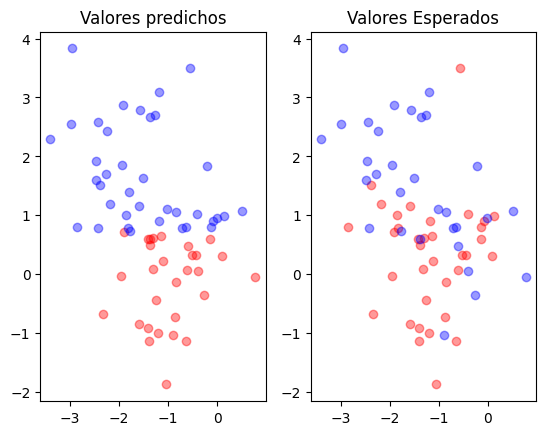

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression( )
clf.fit(X_t,y)
print(clf.score(X_t,y))
y_p = clf.predict(X_p)


plt.subplot(121)
plt.plot(X_p[y_p==0][:,0],X_p[y_p==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_p==1][:,0],X_p[y_p==1][:,1],"bo", alpha=0.4)
plt.title("Valores predichos")

plt.subplot(122)
plt.plot(X_p[y_==0][:,0],X_p[y_==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_==1][:,0],X_p[y_==1][:,1],"bo", alpha=0.4)
plt.title("Valores Esperados")


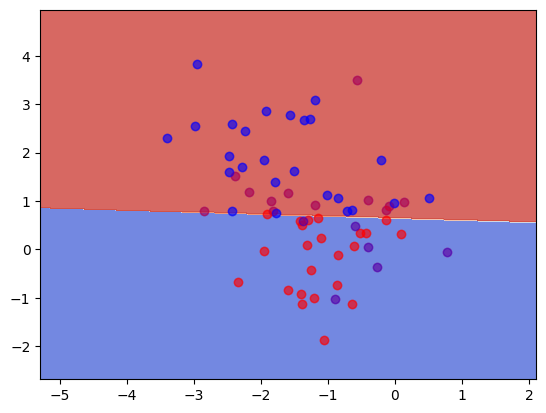

In [ ]:
fig, ax = plt.subplots()
# title for the plots
title = ('Decision surface of linear SVC ')
# Set-up grid for plotting.
X0, X1 = X_t[:, 0], X_t[:, 1]
xx, yy = make_meshgrid(X0, X1)

plt.plot(X_p[y_p==0][:,0],X_p[y_p==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_p==1][:,0],X_p[y_p==1][:,1],"bo", alpha=0.4)

plt.plot(X_p[y_==0][:,0],X_p[y_==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_==1][:,0],X_p[y_==1][:,1],"bo", alpha=0.4)
plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)


## RandomForestClassifier

1.0


Text(0.5, 1.0, 'Valores Esperados')

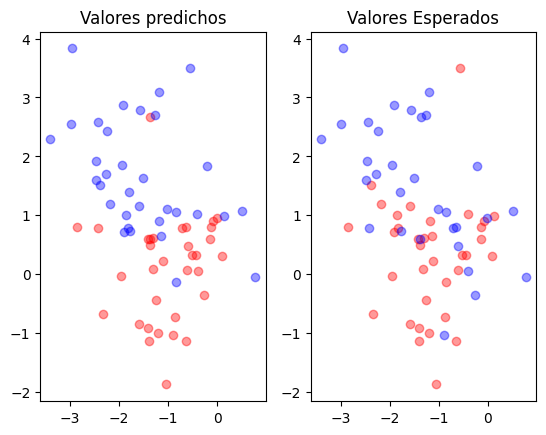

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_t,y)
print(clf.score(X_t,y))
y_p = clf.predict(X_p)

plt.subplot(121)
plt.plot(X_p[y_p==0][:,0],X_p[y_p==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_p==1][:,0],X_p[y_p==1][:,1],"bo", alpha=0.4)
plt.title("Valores predichos")

plt.subplot(122)
plt.plot(X_p[y_==0][:,0],X_p[y_==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_==1][:,0],X_p[y_==1][:,1],"bo", alpha=0.4)
plt.title("Valores Esperados")


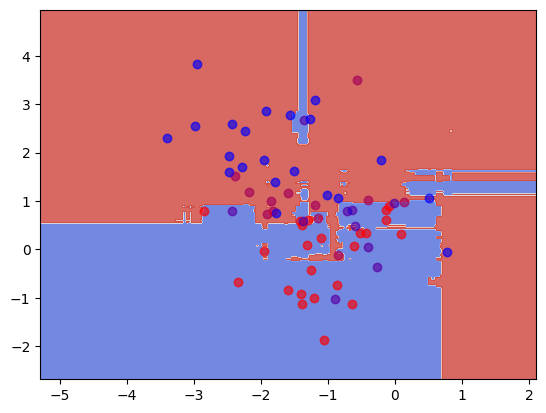

In [ ]:
fig, ax = plt.subplots()
# title for the plots
title = ('Decision surface of linear SVC ')
# Set-up grid for plotting.
X0, X1 = X_t[:, 0], X_t[:, 1]
xx, yy = make_meshgrid(X0, X1)

plt.plot(X_p[y_p==0][:,0],X_p[y_p==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_p==1][:,0],X_p[y_p==1][:,1],"bo", alpha=0.4)

plt.plot(X_p[y_==0][:,0],X_p[y_==0][:,1],"ro", alpha=0.4)
plt.plot(X_p[y_==1][:,0],X_p[y_==1][:,1],"bo", alpha=0.4)
plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)


# Apendice

 Empleando un flujo de trabajo existente de trabajo en  [sklearn](https://scikit-learn.org/stable/auto_examples/svm/plot_iris_svc.html) para los datos de estudio, tenemos que:

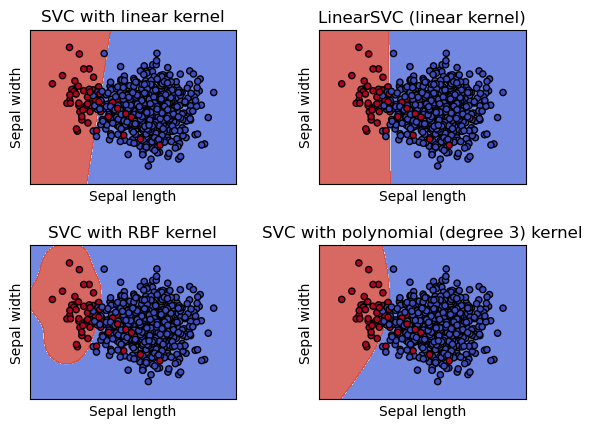

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets


# Take the first two features. We could avoid this by using a two-dim dataset
rv, rv1 = data(mu=[1,1], mu1=[-1.5,1.5],
               cov=[[1.0, 0.0], [0.0, 1.0]] ,
               cov1= [[1.0, -0.5], [-0.5, 1.0]] )

X_t, y = sample()


X_train, X_test, y_train, y_test = train_test_split(X_t, y,
                                                    test_size=0.33,
                                                    random_state=42)


X = X_train
y = y_train
# we create an instance of SVM and fit out data. We do not scale our
# data since we want to plot the support vectors
C = 1.0  # SVM regularization parameter
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=10000),
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
)
models = (clf.fit(X, y) for clf in models)

# title for the plots
titles = (
    "SVC with linear kernel",
    "LinearSVC (linear kernel)",
    "SVC with RBF kernel",
    "SVC with polynomial (degree 3) kernel",
)

# Set-up 2x2 grid for plotting.
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]
xx, yy = make_meshgrid(X0, X1)

for clf, title, ax in zip(models, titles, sub.flatten()):
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel("Sepal length")
    ax.set_ylabel("Sepal width")
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()